# E-Commerce Sales & Customer Analytics
## Python Data Analyst Portfolio Project

### Tools Used:- Python, Pandas, Numpy, Matplotlib
### Project Type:- Exploratory Data Analysis (EDA)
### Dataset:- E-Commerce Transaction Data
### Year:- 2025

## Project objective
The objective of this project is to analyze e-commerce sales
and customer transaction data using Python.

The analysis will help the business understand:

- Sales performance
- Profit performance
- Product performance
- Category performance
- City-wise sales
- Marketing channel performance
- Customer behavior
- Return rates
- Discounts and their impact on profit
- Customer segmentation

## BUSINESS Problem
#### An e-commerce company wants to understand:

* How much sales and profit it is making.
 
* Which products/categories perform best
 
* Which cities generate the most revenue
  
* Which marketing channels perform well
 
* Where returns are high
  
* Which customers are valuable or at risk
  
* Whether discounts affect profit
  
* What business actions should be taken

## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv("C:\\Users\\harsh\\Downloads\\ecommerce_sales_2025 (1).csv")
df.head(10)

,Order_ID,Order_Date,Customer_ID,Gender,Age,City,Category,Product,Quantity,Unit_Price,Discount_Pct,Sales,Cost,Shipping_Cost,Profit,Payment_Method,Delivery_Days,Returned,Rating,Marketing_Channel
0,O107290,2025-01-01,C10733,Female,58,Kolkata,Grocery,Rice,1,902.86,20,722.29,650.06,131.79,-59.56,Debit Card,4,No,4.4,Referral
1,O107269,2025-01-01,C10966,Male,37,Bengaluru,Electronics,Headphones,3,2649.49,15,6756.20,6199.81,127.28,-111.39,COD,3,Yes,3.4,Paid Ads
2,O107253,2025-01-01,C10983,Female,54,Delhi,Beauty,Perfume,1,1716.03,0,1716.03,823.69,66.88,825.46,Debit Card,6,No,4.6,Social Media
3,O107129,2025-01-01,C10084,Female,39,Delhi,Home,Coffee Maker,2,5198.67,10,9357.61,7070.19,111.90,2175.52,Debit Card,2,No,4.6,Organic Search
4,O106847,2025-01-01,C10577,Male,32,Delhi,Fashion,Handbag,2,1812.53,25,2718.80,1885.03,113.95,719.82,COD,6,No,3.8,Paid Ads
5,O101014,2025-01-01,C11231,Female,19,Lucknow,Fashion,T-Shirt,1,853.24,5,810.58,443.68,137.01,229.89,Credit Card,2,No,4.1,Paid Ads
6,O106483,2025-01-01,C11843,Male,57,Hyderabad,Fashion,Handbag,2,1815.44,5,3449.34,1888.06,90.76,1194.57,Net Banking,5,Yes,5.0,Organic Search
7,O111084,2025-01-01,C10250,Male,22,Lucknow,Electronics,Tablet,1,21838.21,10,19654.39,17033.80,54.98,2565.61,COD,3,No,3.2,Organic Search
8,O106121,2025-01-01,C10260,Female,21,Delhi,Grocery,Dry Fruits,3,964.26,15,2458.86,2082.80,95.12,280.94,Credit Card,8,No,4.1,Social Media
9,O105239,2025-01-01,C10783,Male,18,Mumbai,Beauty,Moisturizer,1,731.47,15,621.75,351.11,120.29,150.35,Debit Card,7,No,3.2,Social Media


## Data Inspection

In [3]:
## Check Dataset Size
df.shape

(12060, 20)

In [4]:
## Check Column Names
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Gender', 'Age', 'City',
       'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount_Pct',
       'Sales', 'Cost', 'Shipping_Cost', 'Profit', 'Payment_Method',
       'Delivery_Days', 'Returned', 'Rating', 'Marketing_Channel'],
      dtype='object')

In [5]:
## Understanding Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12060 entries, 0 to 12059
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           12060 non-null  object 
 1   Order_Date         12060 non-null  object 
 2   Customer_ID        12060 non-null  object 
 3   Gender             12060 non-null  object 
 4   Age                12060 non-null  int64  
 5   City               11964 non-null  object 
 6   Category           12060 non-null  object 
 7   Product            12060 non-null  object 
 8   Quantity           12060 non-null  int64  
 9   Unit_Price         12060 non-null  float64
 10  Discount_Pct       12060 non-null  int64  
 11  Sales              12060 non-null  float64
 12  Cost               12060 non-null  float64
 13  Shipping_Cost      12060 non-null  float64
 14  Profit             12060 non-null  float64
 15  Payment_Method     12060 non-null  object 
 16  Delivery_Days      120

In [6]:
## Check Missing Values
df.isnull().sum()

Order_ID              0
Order_Date            0
Customer_ID           0
Gender                0
Age                   0
City                 96
Category              0
Product               0
Quantity              0
Unit_Price            0
Discount_Pct          0
Sales                 0
Cost                  0
Shipping_Cost         0
Profit                0
Payment_Method        0
Delivery_Days         0
Returned              0
Rating               72
Marketing_Channel    60
dtype: int64

In [7]:
## Check Duplicate Data 
df.duplicated().sum()

np.int64(58)

## Data Cleaning

#### The following cleaning steps will be performed:

- Remove duplicate records
- Handle missing city values
- Handle missing ratings
- Handle missing marketing channel values
- Convert Order_Date into datetime format

In [8]:
clean_df = df.drop_duplicates().copy()

clean_df["Order_Date"] = pd.to_datetime(clean_df["Order_Date"])

clean_df["City"] = clean_df["City"].fillna(
    clean_df["City"].mode()[0]
)

clean_df["Rating"] = clean_df["Rating"].fillna(
    clean_df["Rating"].median()
)

clean_df["Marketing_Channel"] = clean_df[
    "Marketing_Channel"
].fillna("Unknown")

In [9]:
## Check Clean Data
clean_df.shape

(12002, 20)

In [10]:
## Create Monthly Column
clean_df["Month"]=clean_df["Order_Date"].dt.to_period("M").astype(str)

In [11]:
clean_df[["Order_Date","Month"]].head()

,Order_Date,Month
0,2025-01-01,2025-01
1,2025-01-01,2025-01
2,2025-01-01,2025-01
3,2025-01-01,2025-01
4,2025-01-01,2025-01


## KPI Analysis (Key Performance Indicator)
### A KPI is an important number that tells us how well the business is performing .
#### For example- 
Total Sales

Total Profit

Total Orders

Total Customers

Average Order Value

Profit Margin

Return Rate


### 1.) Total Sales

In [12]:
total_sales = clean_df["Sales"].sum()
total_sales

np.float64(142033016.44)

### 2.)Total Profit

In [13]:
total_profit = clean_df["Profit"].sum()
total_profit

np.float64(21169321.14)

### 3.)Total Orders

In [14]:
orders = clean_df["Order_ID"].nunique()
orders

12000

### 4.)Total Customers

In [15]:
average_order_value = total_sales / orders
average_order_value

np.float64(11836.084703333334)

### 5.)Profit Margin

In [16]:
profit_margin = total_profit / total_sales * 100
profit_margin

np.float64(14.904507184738067)

### 6.)Return Rate 

In [17]:
return_rate = (
    clean_df["Returned"].eq("Yes").mean() * 100
)
return_rate

np.float64(8.990168305282452)

## EDA- Exploratory Data Analysis
### EDA means examining and exploring the data to find patterns, problems, trends and useful information .
#### It Includes-
1. Monthly Sales Analysis
2. Category Analysis
3. Product Analysis
4. City Analysis
5. Marketing Analysis
6. Returns Analysis
7. Discount Analysis
8. Customer Analysis

### 1.) Monthly Sales Analysis

In [18]:
clean_df["Month"] = clean_df["Order_Date"].dt.to_period("M").astype(str)

monthly = clean_df.groupby("Month").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

monthly

,Month,Sales,Profit,Orders
0,2025-01,12241878.36,1838794.70,1058
1,2025-02,10570333.00,1609770.29,965
2,2025-03,11619626.32,1621907.04,1032
3,2025-04,12789098.67,1802570.55,1004
4,2025-05,11713061.44,1768406.61,1047
5,2025-06,9366580.42,1452844.43,938
6,2025-07,9996241.01,1478672.62,946
7,2025-08,11294499.79,1710166.58,1007
8,2025-09,12799359.53,1853208.27,973
9,2025-10,13787329.83,2184651.51,996


### 2.) Category Analysis

In [19]:
category = clean_df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order_ID", "nunique"),
    Avg_Rating=("Rating", "mean")
).reset_index()

category["Profit_Margin_%"] = (
    category["Profit"] / category["Sales"] * 100
)

category = category.sort_values(
    "Sales",
    ascending=False
)

category.round(2)

,Category,Sales,Profit,Quantity,Orders,Avg_Rating,Profit_Margin_%
1,Electronics,1.104032e+08,13294082.82,4787,2961,4.11,12.04
4,Home,1.971035e+07,4362261.51,3858,2368,4.13,22.13
2,Fashion,6.706890e+06,2466015.05,3883,2409,4.13,36.77
3,Grocery,2.923464e+06,225773.63,4006,2472,4.11,7.72
0,Beauty,2.289103e+06,821188.13,2894,1790,4.13,35.87


In [20]:
## Q)Which category generates the highest sales?
category.head(1)

,Category,Sales,Profit,Quantity,Orders,Avg_Rating,Profit_Margin_%
1,Electronics,1.104032e+08,13294082.82,4787,2961,4.113065,12.041391


### 3.) Product Analysis

In [21]:
product = clean_df.groupby(
    ["Category", "Product"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

product = product.sort_values(
    "Profit",
    ascending=False
)

product.head()

,Category,Product,Sales,Profit,Quantity,Orders
6,Electronics,Laptop,58383438.31,6951142.68,985,605
7,Electronics,Smartphone,27115085.59,3391528.78,985,592
9,Electronics,Tablet,18380124.12,2272476.60,913,595
24,Home,Vacuum Cleaner,6274957.15,1411978.39,769,484
20,Home,Air Fryer,5234311.38,1198983.33,814,487


In [22]:
## Q) Find the highest-profit product in this dataset.
product.loc[product["Profit"].idxmax(),
    ["Product","Profit"]]

Product        Laptop
Profit     6951142.68
Name: 6, dtype: object

### 4.) City Analysis

In [23]:
city = clean_df.groupby("City").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

city = city.sort_values(
    "Sales",
    ascending=False
)
city

,City,Sales,Profit,Orders
3,Delhi,26443332.80,3966520.39,2087
8,Mumbai,17838442.39,2667365.19,1512
1,Bengaluru,17603573.35,2523148.31,1469
4,Hyderabad,14465522.33,2090435.93,1251
2,Chennai,13007405.50,1928921.21,1087
6,Kolkata,11977288.38,1779923.41,1013
9,Pune,11334031.73,1691317.97,1010
0,Ahmedabad,10497641.89,1573303.68,923
7,Lucknow,9646845.68,1505302.03,861
5,Jaipur,9218932.39,1443083.02,788


In [24]:
## Q) Which city generate the most revenue?
city_sales = (
    clean_df.groupby("City")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)
city_sales.head(1)

,City,Sales
3,Delhi,26443332.8


### 5.) Marketing Analysis

In [25]:
marketing_sales = (
    clean_df.groupby("Marketing_Channel")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

marketing_sales

,Marketing_Channel,Sales
2,Organic Search,39001975.78
3,Paid Ads,31672147.16
5,Social Media,23686013.65
0,Direct,17598973.37
4,Referral,16026411.90
1,Email,13334074.79
6,Unknown,713419.79


In [26]:
## Q) Which marketing channels perform well?
marketing_analysis = (
    clean_df.groupby("Marketing_Channel")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Sales", ascending=False)
)

marketing_analysis.head(2)

,Marketing_Channel,Sales,Profit,Orders
2,Organic Search,39001975.78,5857008.14,3275
3,Paid Ads,31672147.16,4768783.09,2655


### 6.) Return Analysis

In [27]:
## Q)How many orders were returned
returns = clean_df["Returned"].value_counts().reset_index()

returns.columns = ["Returned", "Orders"]

returns

,Returned,Orders
0,No,10923
1,Yes,1079


In [28]:
## Return percentage
return_percentage = (
    clean_df["Returned"].eq("Yes").mean() * 100
)

print("Return Rate:", round(return_percentage, 2), "%")

Return Rate: 8.99 %


In [29]:
## Q) Where are returns high?
return_by_city = clean_df[clean_df["Returned"] == "Yes"].groupby("City")["Order_ID"].count()

return_by_city.sort_values(ascending=False)

City
Delhi        187
Bengaluru    136
Mumbai       133
Hyderabad    110
Kolkata      109
Lucknow       90
Chennai       85
Pune          82
Jaipur        79
Ahmedabad     68
Name: Order_ID, dtype: int64

### 7.) Discount Analysis


In [30]:
## How much discount is given on average?
average_discount = clean_df["Discount_Pct"].mean()

print("Average Discount:", round(average_discount, 2), "%")

Average Discount: 10.13 %


In [31]:
## Sales by discount level 
discount_analysis = (
    clean_df.groupby("Discount_Pct")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Discount_Pct")
)
discount_analysis

,Discount_Pct,Sales
0,0,22502798.97
1,5,34872420.08
2,10,38847269.12
3,15,26373662.01
4,20,13701048.59
5,25,5735817.67


### 8.) Customer Analysis 

In [32]:
## Q) Which customers are valuable or at risk?
customer_value = clean_df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False)

customer_value.head()

Customer_ID
C12164    399744.06
C10594    395214.88
C10869    365894.27
C11533    355116.12
C11516    348508.91
Name: Sales, dtype: float64

In [33]:
## Customers at risk
last_purchase = clean_df.groupby("Customer_ID")["Order_Date"].max()

at_risk = last_purchase.sort_values().head()

at_risk

Customer_ID
C11365   2025-01-02
C10251   2025-01-05
C11830   2025-01-11
C10321   2025-01-12
C11053   2025-01-19
Name: Order_Date, dtype: datetime64[ns]

# Data Visualization

### Monthly Sales Analysis

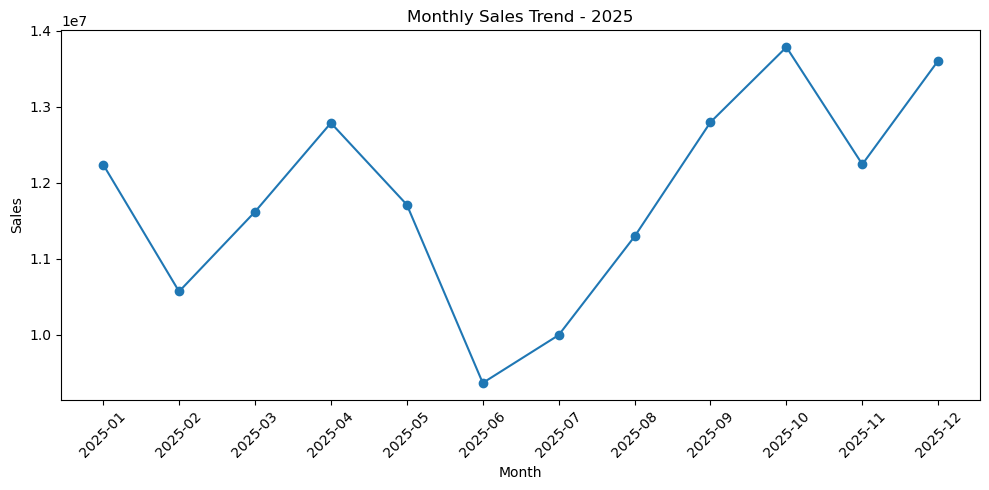

In [34]:

plt.figure(figsize=(10,5))

plt.plot(
    monthly["Month"],
    monthly["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend - 2025")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Discount VS Profit

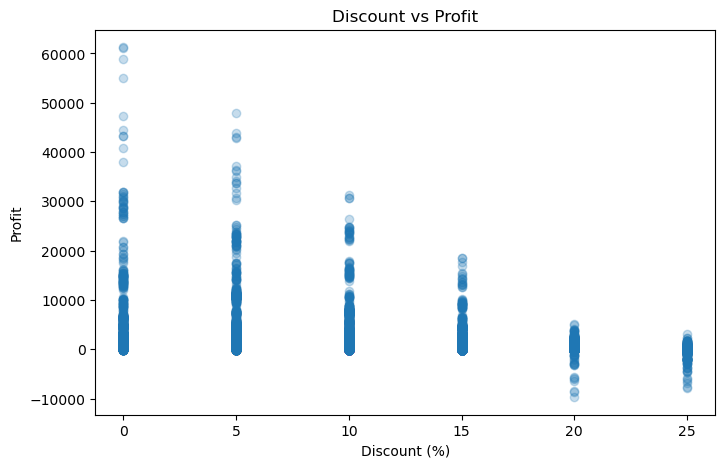

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_df["Discount_Pct"],
    clean_df["Profit"],
    alpha=0.25
)

plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.show()

# Category Sales


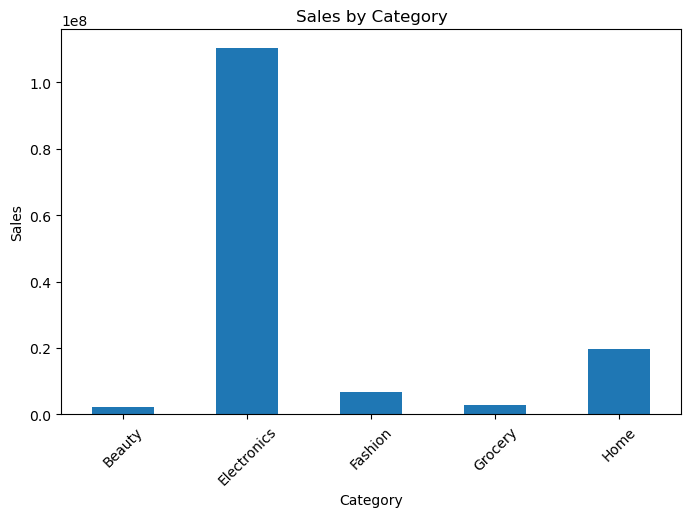

In [36]:
category_sales = clean_df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Sales Distribution 

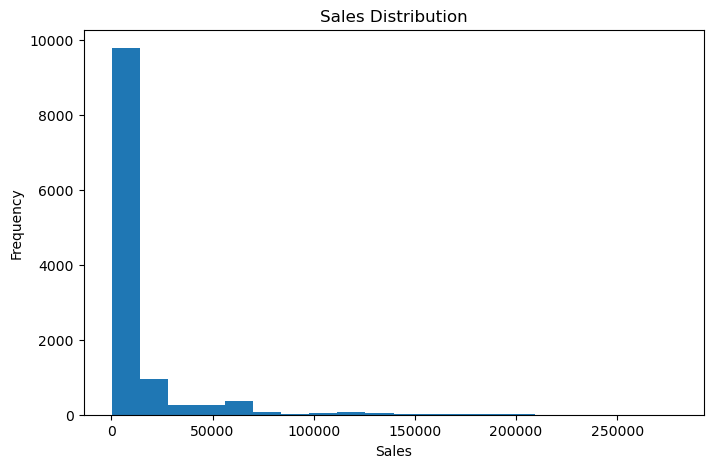

In [37]:
plt.figure(figsize=(8,5))
plt.hist(clean_df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Final results from the project
## KPI RESULT
### Total Sales:- ₹14.20 Crore

### Total Profit:- ₹2.12 Crore

### Orders:- ₹12,000

### Customers:- ₹2,477

### Average Order Value:- ₹11,836

### Profit Margin:- 14.90%

### Return Rate:- 8.99%

### Top Sales Category:- Electronics

### Top Profit Product:- Laptop

### Top Sales City:- Delhi

### Top Sales Channel:- Organic Search

### Highest Return Category:- Grocery 

# Business Recommendations
### Based on the analysis of sales, profit, customers, returns, discounts, and marketing channels, the business can consider these recommendations:
* Focus on high-performing categories.

* Improve low-performing products.

* Control excessive discounts.

* Reduce product returns.

* Target valuable customers.

* Invest in effective marketing channels.

* Improve delivery performance.

* Monitor monthly sales trends.